# AutoEncoder：数据自己教自己压缩

前面的降维方法 PCA 通过线性变换压缩数据，但图像、文本这类高维数据往往包含复杂的非线性结构，线性投影不一定能抓住关键模式。AutoEncoder（自编码器）提供了一种非线性的替代方案——通过训练神经网络将数据压缩到低维再还原，让网络自己学会什么信息值得保留。

本文用 NumPy 从零实现全连接 AutoEncoder（编码器 + 解码器结构，MSE 损失），在手写数字数据集上验证降维和重构效果，并与 PCA 做对比。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.autoencoder import AutoEncoder

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 数据集：Digits

Digits 手写数字数据集（1797 个 8×8=64 维样本），将像素值归一化到 [0, 1] 以匹配 AutoEncoder 的 Sigmoid 输出范围。

In [2]:
digits = load_digits()
X, y = digits.data / 16.0, digits.target  # normalize to [0, 1]
print(f'样本数: {X.shape[0]}, 特征维度: {X.shape[1]}, 类别数: {len(np.unique(y))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}')

样本数: 1797, 特征维度: 64, 类别数: 10
训练集: 1437, 测试集: 360


## 2. 训练 AutoEncoder

设置编码维度为 2（可视化 latent space）。

In [3]:
ae = AutoEncoder(input_dim=64, encoding_dim=2, hidden_dim=32,
                lr=0.1, epochs=200)
ae.fit(X_train)

# 测试集重构误差
X_test_recon = ae.reconstruct(X_test)
test_mse = np.mean((X_test - X_test_recon) ** 2)
print(f'训练损失: {ae.losses_[0]:.6f} -> {ae.losses_[-1]:.6f}')
print(f'测试集 MSE: {test_mse:.6f}')

训练损失: 5.751160 -> 2.025346
测试集 MSE: 0.063365


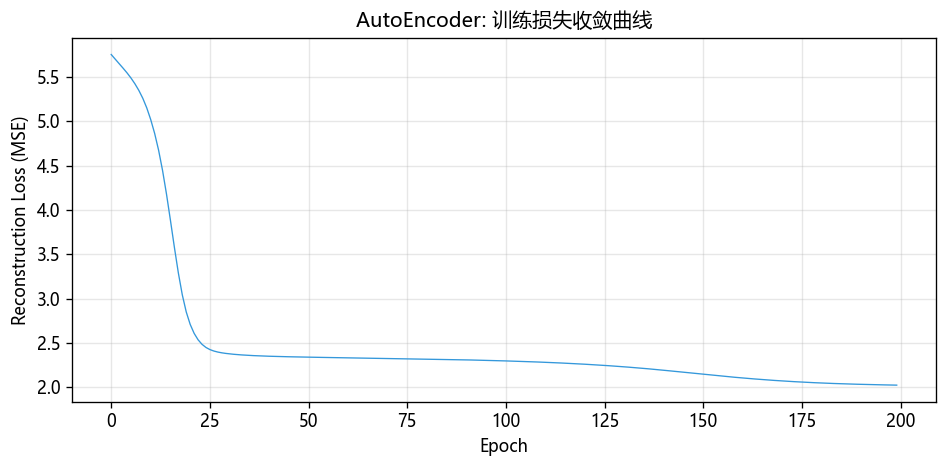

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ae.losses_, color='#3498db', lw=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction Loss (MSE)')
ax.set_title('AutoEncoder: 训练损失收敛曲线')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 重构效果展示

对比测试集中 10 个原始数字和 AutoEncoder 的重构结果。编码维度仅 2 维，可以看到重构虽然模糊，但保留了数字的基本轮廓和类别信息。

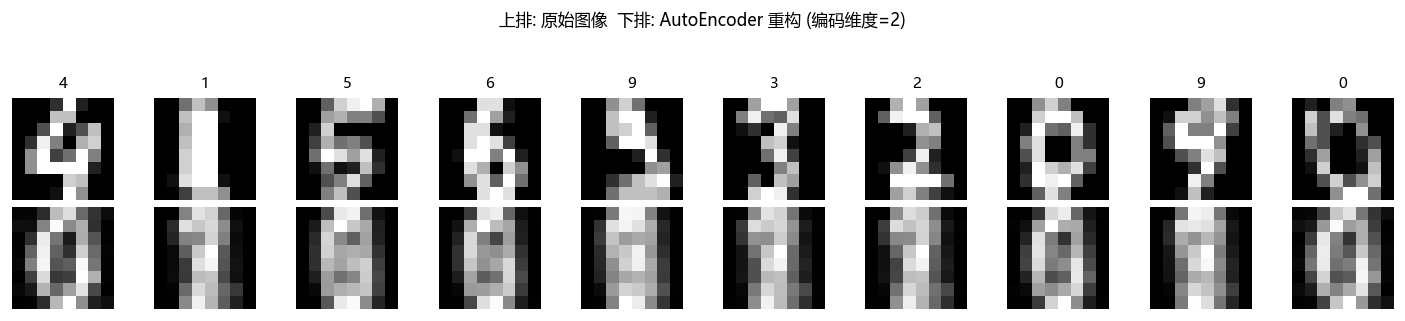

In [5]:
n_show = 10
indices = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(12, 2.5))
fig.suptitle('上排: 原始图像  下排: AutoEncoder 重构 (编码维度=2)',
             fontsize=10, y=1.05)

for i, idx in enumerate(indices):
    axes[0, i].imshow(X_test[idx].reshape(8, 8), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'{y_test[idx]}', fontsize=9)

    recon = X_test_recon[idx].reshape(8, 8)
    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 4. 潜变量空间

将测试集通过编码器映射到 2 维潜变量空间，按数字类别着色。观察不同类是否自然分离。

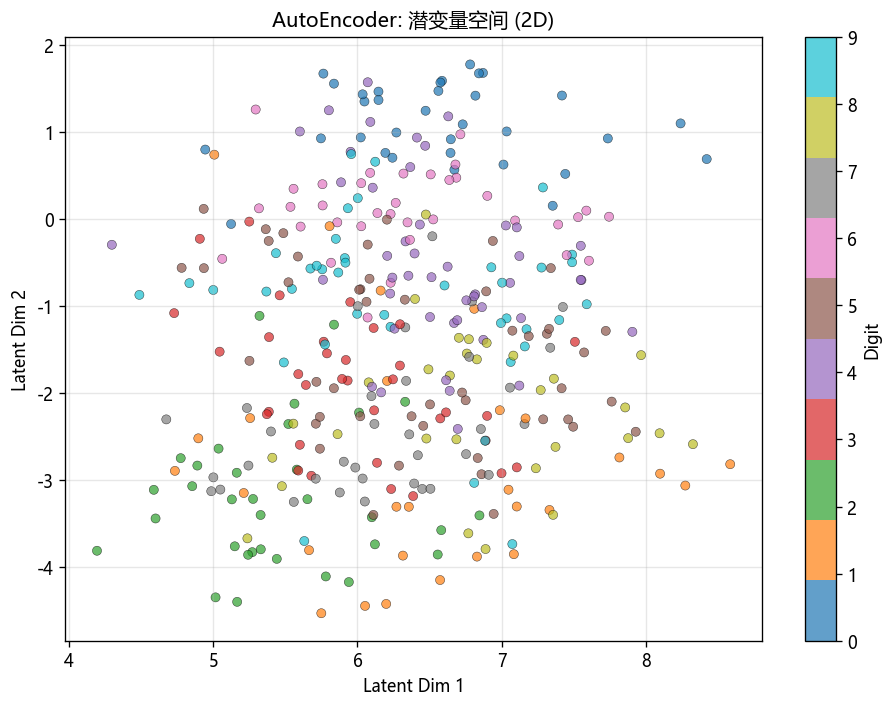

In [6]:
Z_test = ae.encode(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(Z_test[:, 0], Z_test[:, 1], c=y_test,
                    cmap='tab10', alpha=0.7, s=30, edgecolors='k', linewidth=0.3)
ax.set_xlabel('Latent Dim 1')
ax.set_ylabel('Latent Dim 2')
ax.set_title('AutoEncoder: 潜变量空间 (2D)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks(range(10))
cbar.set_label('Digit')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 对比：PCA

作为线性降维的基准，用 PCA 将数据降到 2 维，观察其投影结构与 AutoEncoder 的潜变量有何不同。

C:\Users\zaoquan\AppData\Local\Temp\ipykernel_6924\3180551811.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


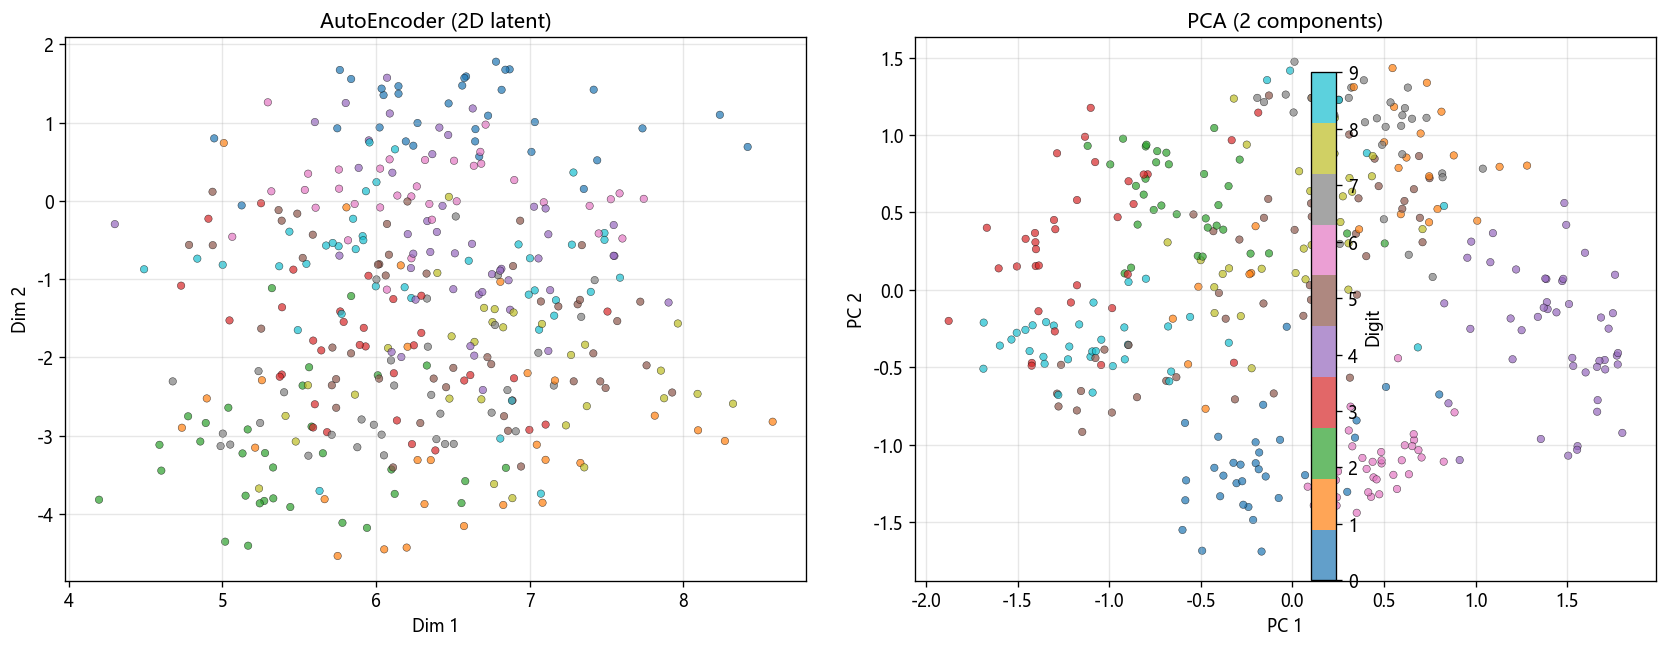

PCA 重构 MSE:       0.051295
AutoEncoder 重构 MSE: 0.063365


In [7]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# AE latent space
sc1 = ax1.scatter(Z_test[:, 0], Z_test[:, 1], c=y_test,
                  cmap='tab10', alpha=0.7, s=20, edgecolors='k', linewidth=0.3)
ax1.set_title('AutoEncoder (2D latent)')
ax1.set_xlabel('Dim 1')
ax1.set_ylabel('Dim 2')
ax1.grid(True, alpha=0.3)

# PCA projection
sc2 = ax2.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
                  cmap='tab10', alpha=0.7, s=20, edgecolors='k', linewidth=0.3)
ax2.set_title('PCA (2 components)')
ax2.set_xlabel('PC 1')
ax2.set_ylabel('PC 2')
ax2.grid(True, alpha=0.3)

fig.colorbar(sc1, ax=[ax1, ax2], ticks=range(10), label='Digit')
plt.tight_layout()
plt.show()

# 重构误差对比
X_test_pca_recon = pca.inverse_transform(X_test_pca)
pca_mse = np.mean((X_test - X_test_pca_recon) ** 2)
print(f'PCA 重构 MSE:       {pca_mse:.6f}')
print(f'AutoEncoder 重构 MSE: {test_mse:.6f}')

## 6. 编码维度 vs 重构质量

固定网络训练配置不变，改变瓶颈维度，观察重构误差的变化。

编码维度= 2  重构 MSE=0.063365


编码维度= 4  重构 MSE=0.048631


编码维度= 8  重构 MSE=0.045161


编码维度=16  重构 MSE=0.036700


编码维度=32  重构 MSE=0.040541


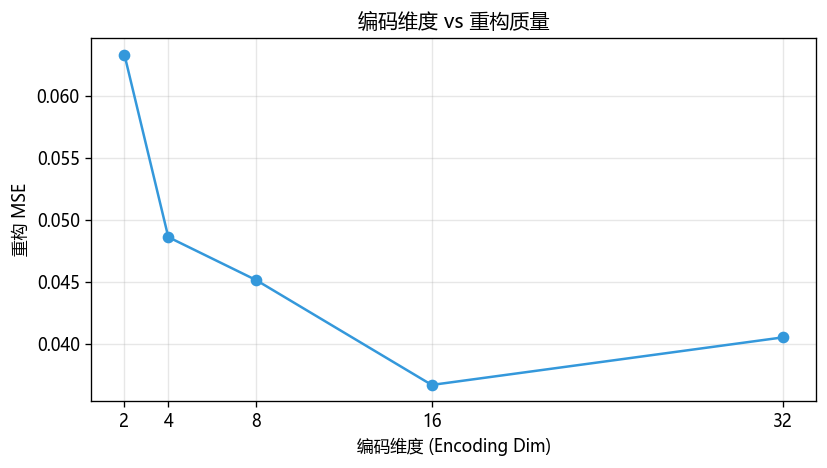

In [8]:
encoding_dims = [2, 4, 8, 16, 32]
mse_scores = []

for k in encoding_dims:
    model = AutoEncoder(input_dim=64, encoding_dim=k, hidden_dim=32,
                        lr=0.1, epochs=200, random_state=42)
    model.fit(X_train)
    X_recon = model.reconstruct(X_test)
    mse = np.mean((X_test - X_recon) ** 2)
    mse_scores.append(mse)
    print(f'编码维度={k:2d}  重构 MSE={mse:.6f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(encoding_dims, mse_scores, 'o-', color='#3498db', lw=1.5, markersize=6)
ax.set_xlabel('编码维度 (Encoding Dim)')
ax.set_ylabel('重构 MSE')
ax.set_title('编码维度 vs 重构质量')
ax.set_xticks(encoding_dims)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 不同编码维度的重构效果对比

选一张测试图片，对比不同编码维度下的重构效果。

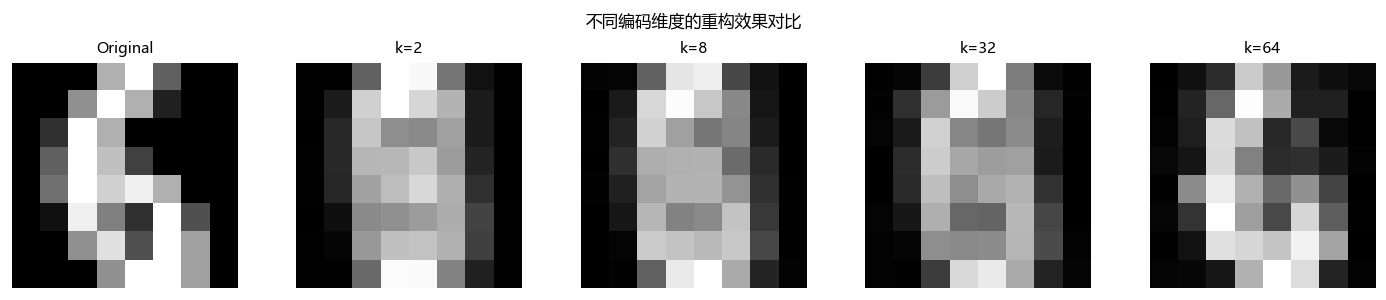

In [9]:
sample_idx = np.random.randint(len(X_test))
original = X_test[sample_idx].reshape(8, 8)

fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

show_dims = [2, 8, 32, 64]
for i, k in enumerate(show_dims):
    model = AutoEncoder(input_dim=64, encoding_dim=k, hidden_dim=32,
                        lr=0.1, epochs=100, random_state=42)
    model.fit(X_train)
    recon = model.reconstruct(X_test[sample_idx:sample_idx+1]).reshape(8, 8)
    axes[i + 1].imshow(recon, cmap='gray')
    axes[i + 1].set_title(f'k={k}', fontsize=9)
    axes[i + 1].axis('off')
plt.suptitle('不同编码维度的重构效果对比', fontsize=10)
plt.tight_layout()
plt.show()

## 小结

- **AutoEncoder** 通过编码器-解码器结构学习数据的压缩表示，是一种非线性的无监督学习方法
- **瓶颈维度** 是压缩率的关键控制参数：维度越低压缩越狠但信息损失也越大，维度越高重构质量越好
- 与 **PCA** 的对比：PCA 做线性投影，AutoEncoder 通过非线性激活函数可以捕捉更复杂的数据结构。在 Digits 数据集上两者 2 维投影的结构差异不大（因为 8×8 的简单图片线性信息已经足够），但在自然图像等高维复杂数据上，AutoEncoder 的非线性优势会更明显
- AutoEncoder 的主要应用方向：**降维**（非线性版 PCA）、**异常检测**（重构误差大的样本可能是异常点）、**去噪**（训练时加噪声让网络学会恢复原图）、**预训练**（逐层训练后作为分类网络初始化）
- 局限：标准 AutoEncoder 的潜变量空间缺乏正则化，可能出现「空洞」——即潜空间中某些区域解码出的结果没有意义。变分自编码器（VAE）通过引入概率分布约束解决了这个问题，也是后面可以深入了解的方向